In [1]:
import numpy as np
from PIL import Image
import pywt
import matplotlib.pyplot as plt
import cv2

# ----------------------------
# 1) Helpers
# ----------------------------
def psnr(x, y, data_range=255.0):
    mse = np.mean((x - y) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(data_range) - 10 * np.log10(mse)

def load_image_gray(path):
    """Load grayscale image and normalize to 0-255 range"""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image from {path}")
    return np.asarray(img).astype(np.float32)

def load_image_rgb(path):
    """Load RGB image and convert BGR->RGB, normalize to 0-255 range"""
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not load image from {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV uses BGR!
    return np.asarray(img).astype(np.float32)

def imshow(t, img, cmap=None):
    """Display image with proper colormap and normalization"""
    plt.figure()
    
    # Auto-detect if grayscale
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    else:
        # RGB image - normalize to 0-1 if needed
        if img.max() > 1.0:
            img_display = img / 255.0
        else:
            img_display = img
        plt.imshow(img_display)
    
    plt.axis('off')
    plt.title(t)
    plt.show()

In [2]:
def dwt(img_gray, wavelet="haar", level=None, mode="symmetric"):
    """
    Returns: coeffs list as from pywt.wavedec2:
      coeffs[0] = cA_L  (approximation at deepest level)
      coeffs[1..L] = (cH, cV, cD) from level L..1
    """
    # Decide max level if not provided
    if level is None:
        # pywt.dwt_max_level expects min dimension
        h, w = img_gray.shape
        level = pywt.dwt_max_level(min(h, w), pywt.Wavelet(wavelet).dec_len)
    coeffs = pywt.wavedec2(img_gray, wavelet=wavelet, mode=mode, level=level)
    return coeffs, level

def idwt(coeffs, wavelet="haar", mode="symmetric"):
    rec = pywt.waverec2(coeffs, wavelet=wavelet, mode=mode)
    return rec

In [3]:
# ----------------------------
# Inspecting coefficient shapes
# ----------------------------
def print_coeffs_info(coeffs):
    """
    coeffs from wavedec2: [cA_L, (cH_L,cV_L,cD_L), ..., (cH_1,cV_1,cD_1)]
    """
    cA = coeffs[0]
    print(f"Level L approximation: {cA.shape}")
    for i, (cH, cV, cD) in enumerate(coeffs[1:], start=1):
        level = len(coeffs) - i
        print(f"Level {level} details: cH{level}{cH.shape}, cV{level}{cV.shape}, cD{level}{cD.shape}")

In [4]:
def visualize_dwt_subbands(coeffs, title="DWT Subbands", figsize=(15, 10), normalize=True):
    """
    Visualize all subbands of a DWT decomposition.
    
    Args:
        coeffs: DWT coefficients from pywt.wavedec2
                [cA_L, (cH_L,cV_L,cD_L), ..., (cH_1,cV_1,cD_1)]
        title: Figure title
        figsize: Figure size
        normalize: Whether to normalize each subband for better visualization
    """
    num_levels = len(coeffs) - 1
    
    # Calculate grid layout
    # We need 1 + 3*num_levels subplots (1 for LL, 3 for each detail level)
    total_subbands = 1 + 3 * num_levels
    cols = min(4, total_subbands)  # Max 4 columns
    rows = (total_subbands + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    fig.suptitle(title, fontsize=16)
    
    # Flatten axes for easier indexing
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    else:
        axes = axes.flatten()
    
    def normalize_coeff(coeff):
        """Normalize coefficient for visualization"""
        if normalize:
            vmin, vmax = np.percentile(coeff, [2, 98])  # Robust normalization
            return np.clip((coeff - vmin) / (vmax - vmin + 1e-8), 0, 1)
        else:
            return coeff
    
    subplot_idx = 0
    
    # 1) Plot approximation (LL) at deepest level
    cA = coeffs[0]
    im = axes[subplot_idx].imshow(normalize_coeff(cA), cmap='gray')
    axes[subplot_idx].set_title(f'LL (Level {num_levels})\n{cA.shape}', fontsize=10)
    axes[subplot_idx].axis('off')
    plt.colorbar(im, ax=axes[subplot_idx], fraction=0.046)
    subplot_idx += 1
    
    # 2) Plot detail coefficients from deepest to shallowest
    for i, (cH, cV, cD) in enumerate(coeffs[1:]):
        level = num_levels - i
        
        # Horizontal details (LH)
        im = axes[subplot_idx].imshow(normalize_coeff(cH), cmap='gray')
        axes[subplot_idx].set_title(f'LH (Level {level})\n{cH.shape}', fontsize=10)
        axes[subplot_idx].axis('off')
        plt.colorbar(im, ax=axes[subplot_idx], fraction=0.046)
        subplot_idx += 1
        
        # Vertical details (HL)
        im = axes[subplot_idx].imshow(normalize_coeff(cV), cmap='gray')
        axes[subplot_idx].set_title(f'HL (Level {level})\n{cV.shape}', fontsize=10)
        axes[subplot_idx].axis('off')
        plt.colorbar(im, ax=axes[subplot_idx], fraction=0.046)
        subplot_idx += 1
        
        # Diagonal details (HH)
        im = axes[subplot_idx].imshow(normalize_coeff(cD), cmap='gray')
        axes[subplot_idx].set_title(f'HH (Level {level})\n{cD.shape}', fontsize=10)
        axes[subplot_idx].axis('off')
        plt.colorbar(im, ax=axes[subplot_idx], fraction=0.046)
        subplot_idx += 1
    
    # Hide unused subplots
    for i in range(subplot_idx, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_dwt_pyramid(coeffs, title="DWT Pyramid View", figsize=(12, 8)):
    """
    Visualize DWT in traditional pyramid layout.
    
    Args:
        coeffs: DWT coefficients from pywt.wavedec2
        title: Figure title
        figsize: Figure size
    """
    num_levels = len(coeffs) - 1
    
    # Find the size of original image (reconstruct to get dimensions)
    if num_levels > 0:
        # Estimate from the finest level detail shapes
        cH1, cV1, cD1 = coeffs[-1]  # Finest level details
        orig_h, orig_w = cH1.shape[0] * 2, cH1.shape[1] * 2
    else:
        orig_h, orig_w = coeffs[0].shape
    
    # Create a composite image showing the pyramid structure
    pyramid_img = np.zeros((orig_h, orig_w))
    
    # Start with the LL approximation at top-left
    cA = coeffs[0]
    h, w = cA.shape
    
    # Normalize for better visualization
    def normalize_for_display(arr):
        arr_norm = arr.copy()
        arr_norm = (arr_norm - arr_norm.min()) / (arr_norm.max() - arr_norm.min() + 1e-8)
        return arr_norm
    
    # Place LL
    pyramid_img[:h, :w] = normalize_for_display(cA)
    
    # Place detail coefficients
    current_h, current_w = h, w
    
    for i, (cH, cV, cD) in enumerate(coeffs[1:]):
        # LH (horizontal details) - top right
        dh, dw = cH.shape
        pyramid_img[:dh, current_w:current_w + dw] = normalize_for_display(cH)
        
        # HL (vertical details) - bottom left  
        pyramid_img[current_h:current_h + dh, :dw] = normalize_for_display(cV)
        
        # HH (diagonal details) - bottom right
        pyramid_img[current_h:current_h + dh, current_w:current_w + dw] = normalize_for_display(cD)
        
        # Update for next level
        current_h, current_w = current_h + dh, current_w + dw
    
    # Display
    plt.figure(figsize=figsize)
    plt.imshow(pyramid_img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    
    # Add text annotations
    plt.text(w//2, h//2, 'LL', ha='center', va='center', color='red', fontweight='bold')
    
    current_h, current_w = h, w
    for i, (cH, cV, cD) in enumerate(coeffs[1:]):
        level = num_levels - i
        dh, dw = cH.shape
        
        # Annotations
        plt.text(current_w + dw//2, dh//2, f'LH{level}', ha='center', va='center', color='blue', fontweight='bold')
        plt.text(dw//2, current_h + dh//2, f'HL{level}', ha='center', va='center', color='green', fontweight='bold')
        plt.text(current_w + dw//2, current_h + dh//2, f'HH{level}', ha='center', va='center', color='orange', fontweight='bold')
        
        current_h, current_w = current_h + dh, current_w + dw
    
    plt.tight_layout()
    plt.show()

[GRAY] Levels used: 2
Level L approximation: (200, 200)
Level 2 details: cH2(200, 200), cV2(200, 200), cD2(200, 200)
Level 1 details: cH1(400, 400), cV1(400, 400), cD1(400, 400)
[GRAY] PSNR: 145.8348 dB


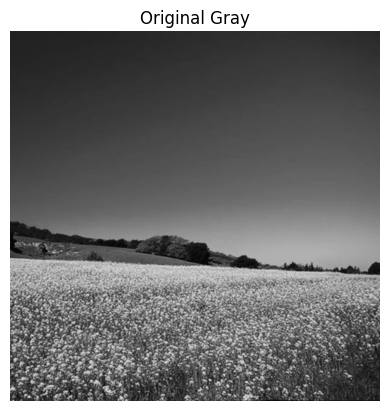

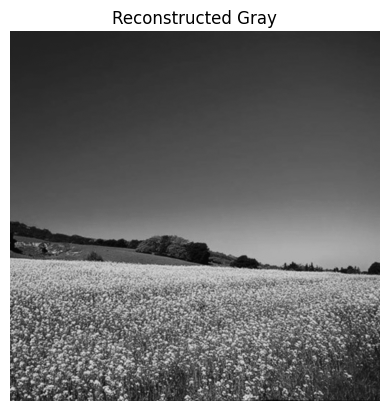

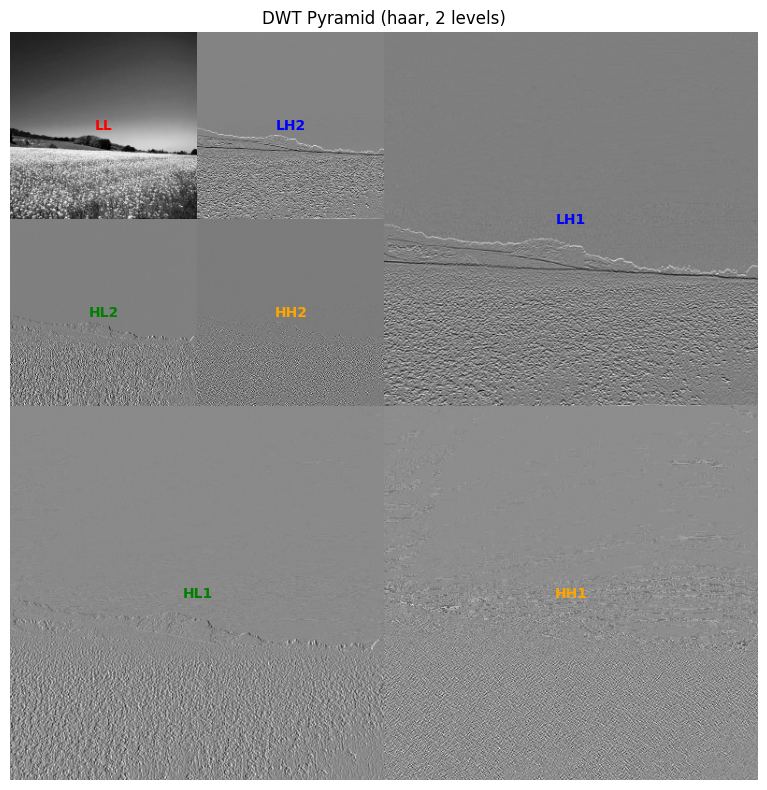

In [5]:
# Change to your image path
path = "./images/i800.png"
wavelet = "haar"
level = 2

# ---- Grayscale demo
g = load_image_gray(path)
coeffs_g, Lg = dwt(g, wavelet=wavelet, level=level, mode="symmetric")
print(f"[GRAY] Levels used: {Lg}")
print_coeffs_info(coeffs_g)

rec_g = idwt(coeffs_g, wavelet=wavelet, mode="symmetric")
rec_g = np.clip(rec_g, 0, 255)
print(f"[GRAY] PSNR: {psnr(g, rec_g):.4f} dB")

imshow('Original Gray', g)
imshow('Reconstructed Gray', rec_g)

# visualize_dwt_subbands(coeffs_g, title=f"DWT Subbands ({wavelet}, {level} levels)", figsize=(15, 10))
visualize_dwt_pyramid(coeffs_g, title=f"DWT Pyramid ({wavelet}, {level} levels)", figsize=(10, 8))

In [6]:
def jpeg_attack(bgr, q=75):
    enc = cv2.imencode(".jpg", bgr, [int(cv2.IMWRITE_JPEG_QUALITY), int(q)])[1]
    return cv2.imdecode(enc, cv2.IMREAD_COLOR)

def rotate_attack(bgr, deg=15):
    H, W = bgr.shape[:2]
    M = cv2.getRotationMatrix2D((W/2, H/2), deg, 1.0)
    return cv2.warpAffine(bgr, M, (W, H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

def scale_attack(bgr, scale=0.8):
    H, W = bgr.shape[:2]
    small = cv2.resize(bgr, (int(W*scale), int(H*scale)), interpolation=cv2.INTER_AREA)
    return cv2.resize(small, (W, H), interpolation=cv2.INTER_CUBIC)

def resize(img, width, height):
    return cv2.resize(img, (width, height), interpolation=cv2.INTER_CUBIC)

In [10]:
import cv2
import numpy as np

def fourier_mellin_transform(image1, image2):
    """
    Computes the rotation and scaling between two images using the Fourier-Mellin Transform.

    Args:
        image1 (np.array): The reference image.
        image2 (np.array): The image to be aligned.

    Returns:
        tuple: A tuple containing the rotation angle (in degrees) and the scaling factor.
    """
    # Step 1: Translation Invariance (using DFT)
    
    # Apply a 2D DFT to both images.
    dft1 = cv2.dft(np.float32(image1), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft2 = cv2.dft(np.float32(image2), flags=cv2.DFT_COMPLEX_OUTPUT)

    # Calculate the magnitude of the DFT results.
    magnitude1 = cv2.magnitude(dft1[:, :, 0], dft1[:, :, 1])
    magnitude2 = cv2.magnitude(dft2[:, :, 0], dft2[:, :, 1])

    # Add a small epsilon to avoid log of zero.
    magnitude1 += 1e-10
    magnitude2 += 1e-10

    # Apply a log transformation to the magnitude.
    log_polar1 = np.log(magnitude1)
    log_polar2 = np.log(magnitude2)

    # Step 2: Log-Polar Transformation
    
    # Get the image dimensions
    rows, cols = image1.shape
    center = (cols / 2, rows / 2)

    # Convert the log-magnitude images to log-polar coordinates.
    log_polar_map1 = cv2.logPolar(log_polar1, center, 40, cv2.WARP_FILL_OUTLIERS)
    log_polar_map2 = cv2.logPolar(log_polar2, center, 40, cv2.WARP_FILL_OUTLIERS)
    
    # Step 3: Finding the Shift (using another DFT and phase correlation)

    # Apply a 2D DFT to the log-polar images.
    dft_lp1 = cv2.dft(np.float32(log_polar_map1), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_lp2 = cv2.dft(np.float32(log_polar_map2), flags=cv2.DFT_COMPLEX_OUTPUT)

    # Calculate the phase correlation between the two log-polar images.
    product = cv2.mulSpectrums(dft_lp1, dft_lp2, 0, conjB=True)
    phase_correlation = cv2.idft(product, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

    # Find the peak in the phase correlation result.
    _, max_val, _, max_loc = cv2.minMaxLoc(phase_correlation)

    # Step 4: Interpreting the Results
    
    # Calculate the shift (rotation and scaling)
    dx = max_loc[0] - cols // 2
    dy = max_loc[1] - rows // 2

    # The horizontal shift corresponds to rotation.
    rotation = -360.0 * (dx / cols)

    # The vertical shift corresponds to scaling.
    scaling_factor = np.exp(dy / 40) # 40 is the 'M' value from logPolar

    return rotation, scaling_factor

# --- Example Usage ---

# Load images (make sure they are in the same folder as the script)
# Replace with your own image paths
img1 = cv2.imread('images/i800.png', 0)
img2 = cv2.imread('images/i800-r.png', 0)

# Check if images are loaded
if img1 is None or img2 is None:
    print("Error: Could not load images.")
else:
    # Resize images to a power of 2 for optimal DFT performance
    size = 256
    scale_factor = 0.8
    img1_resized = cv2.resize(img1, (size, size))
    img2_resized = cv2.resize(img2, (size, size))

    img2_rotated = cv2.rotate(img2_resized, cv2.ROTATE_90_CLOCKWISE)
    img2_scaled = cv2.resize(img2_resized, (int(size * scale_factor), int(size * scale_factor)))

    rotation, scale = fourier_mellin_transform(img1_resized, img2_rotated)
    print(f"Detected Rotation: {rotation:.2f} degrees")
    print(f"Detected Scaling Factor: {scale:.2f}")

    rotation, scale = fourier_mellin_transform(img1_resized, img2_scaled)
    print(f"Detected Rotation: {rotation:.2f} degrees")
    print(f"Detected Scaling Factor: {scale:.2f}")

Detected Rotation: 180.00 degrees
Detected Scaling Factor: 0.20


error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\dxt.cpp:3723: error: (-215:Assertion failed) type == srcB.type() && srcA.size() == srcB.size() in function 'cv::mulSpectrums'


In [ ]:
import cv2
import numpy as np

def embed_watermark(image_path, watermark_vector):
    """
    A skeleton for embedding a watermark using the Fourier-Mellin-like
    transform method described in the paper.
    """
    # 1. Load and Pre-process Image
    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    rows, cols = original_image.shape
    # Ensure image size is a power of 2 for optimal DFT
    size = 2 ** int(np.ceil(np.log2(max(rows, cols))))
    padded_image = np.zeros((size, size), dtype=np.float32)
    padded_image[:rows, :cols] = original_image

    # 2. Extract 1D Signal (v) from the original image
    #    (This step is the same as the detection process)
    #    a. Perform a 2D DFT
    dft = cv2.dft(padded_image, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_magnitude = cv2.magnitude(dft[:,:,0], dft[:,:,1])
    #    b. Resample to log-polar coordinates
    center = (size / 2, size / 2)
    log_polar = cv2.logPolar(dft_magnitude, center, size, cv2.WARP_FILL_OUTLIERS)
    #    c. Sum columns to get the 1D signal (v)
    v = np.sum(np.log(log_polar + 1e-10), axis=0)
    #    (Note: Paper's g1(theta) has more specific logic for symmetry)

    # 3. Create the "Mixed" Signal (s)
    #    This is a conceptual step. The mixing function f(v, w)
    #    combines the original signal v and watermark w
    #    The result s should be similar to v but have high correlation with w.
    #    (This is a complex part not fully specified in the abstract)
    #    For simplicity, let's assume a basic additive mixing:
    s = v + watermark_vector

    # 4. Modify the Original Image's Fourier Transform
    #    This is the core inverse problem.
    #    a. Modify log-polar data to produce s on detection
    #       (This is mathematically complex and difficult to implement directly)
    modified_log_polar = np.copy(log_polar)
    for j in range(cols):
        current_sum = np.sum(np.log(modified_log_polar[:, j]))
        target_sum = s[j]
        # Modify the column to make its log sum equal s[j]
        modified_log_polar[:, j] *= np.exp((target_sum - current_sum) / rows)

    #    b. Resample back to Cartesian coordinates
    modified_magnitude = cv2.linearPolar(modified_log_polar, center, size, cv2.WARP_FILL_OUTLIERS)
    
    # 5. Apply new magnitude to original DFT phases
    #    This creates the new, watermarked DFT
    original_phase = cv2.phase(dft[:, :, 0], dft[:, :, 1])
    complex_real = modified_magnitude * np.cos(original_phase)
    complex_imag = modified_magnitude * np.sin(original_phase)
    modified_dft = np.stack((complex_real, complex_imag), axis=2)

    # 6. Inverse DFT to get the watermarked image
    watermarked_image_full = cv2.idft(modified_dft, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)
    watermarked_image = watermarked_image_full[:rows, :cols].astype(np.uint8)

    return watermarked_image

In [13]:
# pip install opencv-contrib-python numpy scipy pillow

import cv2
import numpy as np
from scipy.fftpack import dct, idct
from PIL import Image

# ---------------------
# Config
# ---------------------
PATCH_SIZE = 32           # canonical patch size (square)
EMBED_POS = [(4,3), (3,4), (5,2), (2,5)]  # midband DCT coords per bit (cycled)
DELTA = 3.0               # QIM step (tune for invisibility/robustness)
GRID = (8, 8)             # spatial tiling
RMIN = 0.001              # min response
SCALE_RANGE = (2.0, 128.0) # acceptable keypoint sizes
REPEAT = 3                # repeat each bit across 5 KPs
MAX_BITS = 128            # payload length (demo)

# ---------------------
# Helpers
# ---------------------
def to_gray(img_path):
    return np.asarray(Image.open(img_path).convert('L')).astype(np.float32)

def make_sift():
    # Use fixed params for determinism across runs
    return cv2.SIFT_create(
        nfeatures=0,
        nOctaveLayers=3,
        contrastThreshold=0.04,
        edgeThreshold=10,
        sigma=1.6
    )

def detect_kps(img):
    sift = make_sift()
    kps, desc = sift.detectAndCompute((img/img.max()).astype(np.uint8), None)
    return kps, desc

def filter_kps(kps, h, w):
    # keep only robust ones
    keep = []
    for kp in kps:
        if kp.response < RMIN:           continue
        if not (SCALE_RANGE[0] <= kp.size <= SCALE_RANGE[1]): continue
        x,y = kp.pt
        if x<=1 or y<=1 or x>=w-2 or y>=h-2: continue
        keep.append(kp)
    return keep

def grid_select(kps, img_shape):
    """Pick at most 1 keypoint per grid cell using stable tie-breakers."""
    h,w = img_shape
    gr, gc = GRID
    cell_h, cell_w = h/gr, w/gc
    buckets = {}

    for kp in kps:
        x,y = kp.pt
        r = min(gr-1, int(y // cell_h))
        c = min(gc-1, int(x // cell_w))
        buckets.setdefault((r,c), []).append(kp)

    chosen = []
    for (r,c), arr in buckets.items():
        # Stable sort: by (-response, -size, y, x)
        arr.sort(key=lambda k:(-k.response, -k.size, k.pt[1], k.pt[0]))
        chosen.append(arr[0])

    # Final stable order: (octave, round(size,2), r, c, y, x)
    def keyf(k):
        x,y = k.pt
        return (k.octave, round(k.size,2), int(y//cell_h), int(x//cell_w), y, x)
    chosen.sort(key=keyf)
    return chosen

def extract_canonical_patch(img, kp, ps=PATCH_SIZE):
    """Rotate/scale-normalize a patch around the keypoint to ps×ps."""
    x,y = kp.pt
    angle = kp.angle    # degrees, [0,360)
    scale = kp.size     # diameter of the meaningful keypoint region

    # Map canonical square to source via inverse warp
    # Build transform: first, rotate by -angle and scale by (scale->canonical)
    # We want: source_patch -> canonical
    M = cv2.getRotationMatrix2D((x,y), angle, 1.0)
    # To get a fixed-sized canonical patch, we warp around the kp with scale factor
    # We'll crop a square around (x,y) whose "effective" size is proportional to scale
    # Trick: build a transform from source to a patch centered at (ps/2, ps/2)
    s = (ps/ (scale + 1e-6))  # normalize so kp.size maps to patch size
    M_norm = cv2.getRotationMatrix2D((x,y), angle, s)
    # shift output so kp goes to patch center
    M_norm[0,2] += (ps/2 - x*s*np.cos(np.deg2rad(angle)) + y*s*np.sin(np.deg2rad(angle)))
    M_norm[1,2] += (ps/2 - x*s*np.sin(np.deg2rad(angle)) - y*s*np.cos(np.deg2rad(angle)))

    patch = cv2.warpAffine(img, M_norm, (ps, ps), flags=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_REFLECT)
    return patch, M_norm

def paste_patch(img, patch, M_norm, alpha=1.0):
    """Inverse-warp the modified canonical patch back to image coords."""
    # Inverse warp: from patch coords back to image
    Minv = cv2.invertAffineTransform(M_norm)
    h,w = img.shape
    back = cv2.warpAffine(patch, Minv, (w, h), flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_REFLECT)
    if alpha >= 1.0:
        return back  # replaces pixels where patch places values
    # Soft blend (optional)
    mask = np.ones_like(patch, dtype=np.float32)
    mask_back = cv2.warpAffine(mask, Minv, (w, h), flags=cv2.INTER_LINEAR,
                               borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    out = img*(1-mask_back*(alpha)) + back*(mask_back*(alpha))
    return out

def dct2(x):  return dct(dct(x.T, norm='ortho').T, norm='ortho')
def idct2(X): return idct(idct(X.T, norm='ortho').T, norm='ortho')

def qim_embed(coeff, bit, delta=DELTA):
    # two quantizers: centers at {..., -3Δ/2, -Δ/2, Δ/2, 3Δ/2, ...}
    q = np.round((coeff - (delta/2 if bit else -delta/2)) / delta) * delta + (delta/2 if bit else -delta/2)
    return q

def qim_decode(coeff, delta=DELTA):
    # choose nearest lattice
    d0 = abs((coeff % (2*delta)) - (-delta/2 % (2*delta)))
    d1 = abs((coeff % (2*delta)) - ( delta/2 % (2*delta)))
    return 1 if d1 < d0 else 0

# ---------------------
# Embedding
# ---------------------
def embed_watermark(host_img, bits):
    img = host_img.copy()
    h,w = img.shape
    kps,_ = detect_kps(img)
    kps = filter_kps(kps, h, w)
    kps = grid_select(kps, img.shape)

    if len(kps) == 0:
        raise RuntimeError("No stable SIFT keypoints found with current thresholds.")

    # Plan repetition mapping: spread each bit across REPEAT keypoints
    # Use cycling across the selected keypoints
    assignments = []
    idx = 0
    for b in bits:
        idxs = []
        for _ in range(REPEAT):
            idxs.append(idx % len(kps))
            idx += 1
        assignments.append(idxs)

    for bit_i, kp_idxs in enumerate(assignments):
        for j, kpi in enumerate(kp_idxs):
            kp = kps[kpi]
            patch, M = extract_canonical_patch(img, kp)
            P = patch.astype(np.float32)

            # DCT midband QIM (use multiple coeffs for reliability)
            C = dct2(P)
            (u,v) = EMBED_POS[(bit_i + j) % len(EMBED_POS)]
            C[u,v] = qim_embed(C[u,v], int(bits[bit_i]), DELTA)

            P2 = idct2(C)
            P2 = np.clip(P2, 0, 255)

            img = paste_patch(img, P2, M, alpha=1.0)

    return np.clip(img, 0, 255)

# ---------------------
# Extraction (blind)
# ---------------------
def extract_watermark(wm_img, payload_len):
    img = wm_img.copy()
    h,w = img.shape
    kps,_ = detect_kps(img)
    kps = filter_kps(kps, h, w)
    kps = grid_select(kps, img.shape)
    if len(kps) == 0:
        raise RuntimeError("No stable SIFT keypoints found with current thresholds.")

    votes = [[] for _ in range(payload_len)]
    idx = 0
    for bit_i in range(payload_len):
        for rep in range(REPEAT):
            kpi = idx % len(kps)
            idx += 1
            kp = kps[kpi]
            patch, M = extract_canonical_patch(img, kp)
            P = patch.astype(np.float32)
            C = dct2(P)
            (u,v) = EMBED_POS[(bit_i + rep) % len(EMBED_POS)]
            bit = qim_decode(C[u,v], DELTA)
            votes[bit_i].append(bit)

    # Majority vote
    bits = [1 if sum(v)>=(len(v)/2) else 0 for v in votes]
    return bits

# ---------------------
# Quick demo
# ---------------------
if __name__ == "__main__":
    # Load grayscale host
    host = to_gray("./images/cat.webp")
    # Payload (toy): 64 bits
    rng = np.random.RandomState(0)
    payload = rng.randint(0, 2, size=min(MAX_BITS, 64)).tolist()

    wm = embed_watermark(host, payload)

    # Simulate mild attacks (rotate + scale + JPEG-like blur)
    M = cv2.getRotationMatrix2D((wm.shape[1]/2, wm.shape[0]/2), 12, 0.85)
    attacked = cv2.warpAffine(wm, M, (wm.shape[1], wm.shape[0]), flags=cv2.INTER_LINEAR,
                              borderMode=cv2.BORDER_REFLECT)
    attacked = cv2.GaussianBlur(attacked, (3,3), 0.6)

    rec = extract_watermark(attacked, len(payload))
    acc = np.mean(np.array(rec)==np.array(payload))
    print(f"Recovered accuracy: {acc:.3f} ({sum(np.array(rec)==np.array(payload))}/{len(payload)})")


RuntimeError: No stable SIFT keypoints found with current thresholds.

# LPT

PSNR (host vs watermarked): 8.973352406918293 dB


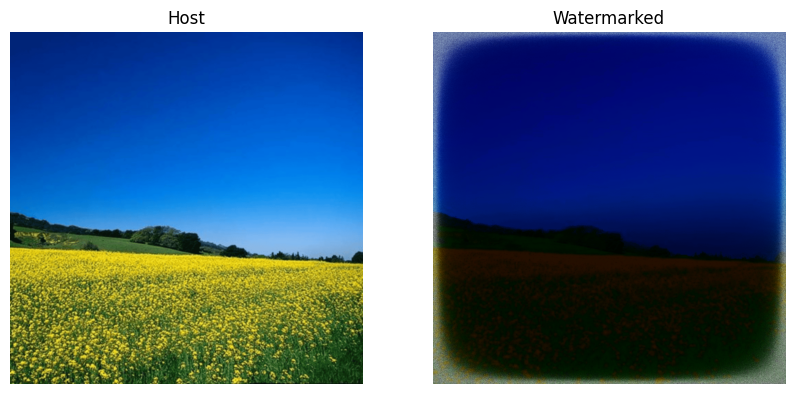

Recovered watermark BER: 0.6172 (632/1024 errors)


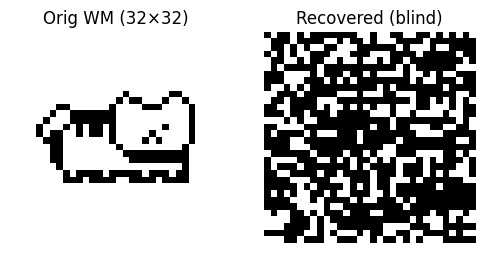

In [17]:
# ============================================================
# Blind Watermarking in Fourier-Mellin (LPT) + Block-DCT + QIM
#   - RST invariance: via FFT magnitude -> Log-Polar Transform
#   - Robustness: mid-band DCT + dithered QIM + repetition + Hamming(7,4)
#   - Sync: pilot PN stripes for angle (θ) & radius (ρ) shift correction
#   - Color host supported (embed on Y only)
#   - Watermark: 32x32 binary image (auto-binarized)
#
# Author: (Your Name)
# ============================================================

import cv2
import numpy as np
from PIL import Image
import math
import matplotlib.pyplot as plt

# --------------- Utility: image I/O ---------------

def load_rgb(path):
    img = Image.open(path).convert('RGB')
    return np.array(img)

def save_rgb(path, img_rgb_uint8):
    Image.fromarray(img_rgb_uint8).save(path)

def to_ycbcr(img_rgb_uint8):
    ycbcr = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2YCrCb)
    Y, Cr, Cb = ycbcr[...,0].astype(np.float32), ycbcr[...,1], ycbcr[...,2]
    return Y, Cb, Cr

def from_ycbcr(Y_float, Cb_uint8, Cr_uint8):
    Y_clip = np.clip(Y_float, 0, 255).astype(np.uint8)
    ycbcr = np.stack([Y_clip, Cr_uint8, Cb_uint8], axis=-1)
    rgb = cv2.cvtColor(ycbcr, cv2.COLOR_YCrCb2RGB)
    return rgb

def psnr(a, b):
    a = a.astype(np.float32); b = b.astype(np.float32)
    mse = np.mean((a - b) ** 2)
    if mse == 0: return 99.0
    return 10 * math.log10(255 * 255 / mse)

# --------------- Watermark prep (32x32 binary) ---------------

def load_binary_watermark(path, size=(32,32)):
    """Load any image and convert to 32x32 binary (0/1)."""
    img = Image.open(path).convert('L').resize(size, Image.BILINEAR)
    arr = np.array(img).astype(np.float32)
    thr = 0.5 * (arr.max() + arr.min())
    bits = (arr > thr).astype(np.uint8)
    return bits  # shape (32,32), values {0,1}

# --------------- FFT magnitude <-> LPT helpers ---------------

def fft_mag_phase(y_float):
    F = np.fft.fft2(y_float)
    Mag = np.abs(F)
    Phase = np.angle(F)
    return Mag, Phase

def ifft_from_mag_phase(Mag, Phase):
    F = Mag * np.exp(1j * Phase)
    y = np.fft.ifft2(F)
    return np.real(y)

def log_polar(img_float, rho_size=384, theta_size=1024, center=None, max_radius=None):
    """
    Forward log-polar using OpenCV warpPolar.
    Output shape: (rho_size, theta_size)
    """
    h, w = img_float.shape
    if center is None:
        center = (w/2.0, h/2.0)
    if max_radius is None:
        max_radius = min(center[0], center[1], w-center[0], h-center[1])
    # OpenCV expects size (theta_size, rho_size) as (width, height)
    lpt = cv2.warpPolar(
        img_float, (theta_size, rho_size),
        center, max_radius,
        cv2.WARP_POLAR_LOG + cv2.WARP_FILL_OUTLIERS
    )
    # lpt shape: (rho_size, theta_size)
    return lpt, center, max_radius

def inv_log_polar(lpt_float, out_shape, center, max_radius):
    h, w = out_shape
    cart = cv2.warpPolar(
        lpt_float, (w, h),
        center, max_radius,
        cv2.WARP_POLAR_LOG + cv2.WARP_FILL_OUTLIERS + cv2.WARP_INVERSE_MAP
    )
    return cart

# --------------- Pilot PN Stripes (sync for θ and ρ) ---------------

def rng_from_key(key: str):
    # deterministic 32-bit seed
    seed = np.frombuffer(key.encode('utf-8'), dtype=np.uint8).sum() & 0xffffffff
    return np.random.RandomState(int(seed))

def gen_pn(length, rng):
    return rng.choice([-1.0, 1.0], size=(length,)).astype(np.float32)

def add_pilot_stripes(M_norm, key, pilot_strength=0.05, rho_idx_frac=0.30, theta_idx_frac=0.60):
    """
    Add two weak PN stripes into normalized LPT image M_norm:
      - Horizontal stripe at fixed rho index: detects θ circular shift
      - Vertical stripe at fixed theta index: detects ρ circular shift
    """
    H, W = M_norm.shape  # (rho, theta)
    rng = rng_from_key(key + "::pilot")
    rho_idx = int(round(rho_idx_frac * H))  # row index (fixed radius)
    theta_idx = int(round(theta_idx_frac * W))  # column index (fixed angle)

    pn_theta = gen_pn(W, rng)   # across theta (horizontal stripe)
    pn_rho   = gen_pn(H, rng)   # across rho   (vertical stripe)

    M_mod = M_norm.copy()
    M_mod[rho_idx, :] += pilot_strength * pn_theta
    M_mod[:, theta_idx] += pilot_strength * pn_rho

    pilot_meta = {
        "rho_idx": rho_idx,
        "theta_idx": theta_idx,
        "pn_theta": pn_theta,
        "pn_rho": pn_rho
    }
    return M_mod, pilot_meta

def circ_corr_1d(x, y):
    """Circular cross-correlation via FFT; returns the shift (int) maximizing correlation."""
    X = np.fft.fft(x)
    Y = np.fft.fft(y)
    corr = np.fft.ifft(X * np.conj(Y))
    k = int(np.argmax(np.real(corr)))
    return k

def estimate_shifts(M_norm, pilot_meta):
    """Estimate circular shifts along θ and ρ using the pilot stripes."""
    rho_idx = pilot_meta["rho_idx"]
    theta_idx = pilot_meta["theta_idx"]
    pn_theta = pilot_meta["pn_theta"]
    pn_rho = pilot_meta["pn_rho"]

    # θ shift (horizontal stripe at rho_idx)
    row = M_norm[rho_idx, :]
    k_theta = circ_corr_1d(row, pn_theta)  # how much row is shifted relative to PN

    # ρ shift (vertical stripe at theta_idx)
    col = M_norm[:, theta_idx]
    k_rho = circ_corr_1d(col, pn_rho)

    return k_rho, k_theta  # integers in [0..H-1], [0..W-1]

def apply_circular_shift_2d(M, shift_rho, shift_theta):
    """Circularly shift M by (shift_rho along axis 0, shift_theta along axis 1)."""
    M2 = np.roll(M, shift_rho, axis=0)
    M2 = np.roll(M2, shift_theta, axis=1)
    return M2

# --------------- Block DCT helpers ---------------

MIDBAND_POS = [
    (0,5),(0,6),(1,4),(1,5),(1,6),
    (2,3),(2,4),(2,5),
    (3,2),(3,3),(3,4),
    (4,2),(4,3),
    (5,1),(5,2)
]

def block_process(img, block=8):
    H, W = img.shape
    Hc = (H // block) * block
    Wc = (W // block) * block
    return img[:Hc, :Wc], Hc, Wc

def dct2_blockwise(img, block=8):
    img_cropped, Hc, Wc = block_process(img, block)
    out = np.zeros_like(img_cropped, dtype=np.float32)
    for r in range(0, Hc, block):
        for c in range(0, Wc, block):
            patch = img_cropped[r:r+block, c:c+block].astype(np.float32)
            out[r:r+block, c:c+block] = cv2.dct(patch)
    return out

def idct2_blockwise(coef, block=8):
    coef_cropped, Hc, Wc = block_process(coef, block)
    out = np.zeros_like(coef_cropped, dtype=np.float32)
    for r in range(0, Hc, block):
        for c in range(0, Wc, block):
            patch = coef_cropped[r:r+block, c:c+block].astype(np.float32)
            out[r:r+block, c:c+block] = cv2.idct(patch)
    return out

# --------------- QIM (dithered) ---------------

def qim_embed_scalar(s, bit, Delta):
    # dithers for bit 0 and 1:
    d0 = -Delta/4.0
    d1 = +Delta/4.0
    d  = d1 if bit == 1 else d0
    return Delta * np.round((s - d)/Delta) + d

def qim_decode_scalar(s, Delta):
    d0 = -Delta/4.0
    d1 = +Delta/4.0
    r0 = abs(s - d0 - Delta * np.round((s - d0)/Delta))
    r1 = abs(s - d1 - Delta * np.round((s - d1)/Delta))
    return 1 if r1 < r0 else 0

# --------------- Hamming(7,4) + Repetition ---------------

def hamming74_encode(bits):
    """bits length multiple of 4; returns length * 7/4."""
    bits = np.asarray(bits).astype(np.uint8)
    assert bits.size % 4 == 0
    out = []
    for i in range(0, bits.size, 4):
        d1, d2, d3, d4 = bits[i:i+4]
        p1 = d1 ^ d2 ^ d4
        p2 = d1 ^ d3 ^ d4
        p3 = d2 ^ d3 ^ d4
        code = [p1, p2, d1, p3, d2, d3, d4]
        out.extend(code)
    return np.array(out, dtype=np.uint8)

def hamming74_decode(codebits):
    """codebits length multiple of 7; returns data bits length * 4/7 (with 1-bit correction per codeword)."""
    codebits = np.asarray(codebits).astype(np.uint8)
    assert codebits.size % 7 == 0
    out = []
    for i in range(0, codebits.size, 7):
        p1, p2, d1, p3, d2, d3, d4 = codebits[i:i+7].tolist()
        s1 = p1 ^ d1 ^ d2 ^ d4
        s2 = p2 ^ d1 ^ d3 ^ d4
        s3 = p3 ^ d2 ^ d3 ^ d4
        syndrome = (s3 << 2) | (s2 << 1) | s1  # 1..7
        cw = [p1, p2, d1, p3, d2, d3, d4]
        if syndrome != 0 and 1 <= syndrome <= 7:
            cw[syndrome - 1] ^= 1  # correct
            p1, p2, d1, p3, d2, d3, d4 = cw
        out.extend([d1, d2, d3, d4])
    return np.array(out, dtype=np.uint8)

def repeat_bits(bits, R):
    bits = np.asarray(bits).astype(np.uint8)
    return np.repeat(bits, R)

def repeat_decode(voted_bits, R):
    """Majority vote over each group of R."""
    voted_bits = np.asarray(voted_bits).astype(np.uint8)
    assert voted_bits.size % R == 0
    out = []
    for i in range(0, voted_bits.size, R):
        grp = voted_bits[i:i+R]
        out.append(1 if grp.sum() >= (R/2.0) else 0)
    return np.array(out, dtype=np.uint8)

# --------------- Mapping of bits to blocks/coefs (keyed) ---------------

def make_mapping(key, Hc, Wc, block=8, num_code_bits=0, R=16):
    """Return lists (block_positions, midband_indices) of length total_assignments = num_code_bits*R."""
    rng = rng_from_key(key + "::map")
    nb_r = Hc // block
    nb_c = Wc // block
    all_blocks = [(br, bc) for br in range(nb_r) for bc in range(nb_c)]
    rng.shuffle(all_blocks)

    total_needed = num_code_bits * R
    if total_needed > len(all_blocks):
        raise ValueError(f"Not enough blocks for embedding: need {total_needed}, have {len(all_blocks)}. "
                         f"Reduce R or image size / increase LPT grid.")

    # Choose a mid-band coef index per block
    mid_positions = MIDBAND_POS
    coef_choices = [mid_positions[rng.randint(0, len(mid_positions))] for _ in range(total_needed)]

    return all_blocks[:total_needed], coef_choices

# --------------- Main: EMBED ---------------

def embed_watermark(
    host_rgb_path, wm_path, key="vin-sen-secret",
    rho_size=384, theta_size=1024,
    qim_Delta=3.0,  # QIM step in z-scored LPT units
    pilot_strength=0.05,
    R=16,  # repetition
    use_window=True
):
    # -- Load host and get Y/Cb/Cr
    host = load_rgb(host_rgb_path)
    Y, Cb, Cr = to_ycbcr(host)
    H, W = Y.shape

    # optional apodization to reduce spectral border effects
    if use_window:
        wy = np.hanning(H); wx = np.hanning(W)
        window = np.outer(wy, wx).astype(np.float32)
        Yw = Y * window
    else:
        Yw = Y

    # -- FFT magnitude/phase
    Mag, Phase = fft_mag_phase(Yw)
    LogMag = np.log1p(Mag)

    # -- LPT of log-magnitude
    M_lp, center, maxR = log_polar(LogMag, rho_size=rho_size, theta_size=theta_size)

    # -- Normalize (z-score) for stable QIM thresholds
    mu, sigma = np.mean(M_lp), np.std(M_lp) + 1e-6
    M_norm = (M_lp - mu) / sigma

    # -- Add pilot PN stripes
    M_pilot, pilot_meta = add_pilot_stripes(M_norm, key, pilot_strength=pilot_strength)

    # -- DCT (8x8) on M_pilot
    D = dct2_blockwise(M_pilot, block=8)
    D_cropped, Hc, Wc = block_process(D, 8)

    # -- Prepare watermark bits (32x32 -> 1024 bits)
    wm_bits_img = load_binary_watermark(wm_path, size=(32,32))
    wm_bits = wm_bits_img.flatten().astype(np.uint8)

    # -- ECC: Hamming(7,4) then repetition
    wm_bits_pack = hamming74_encode(wm_bits.reshape(-1,4).flatten())
    code_bits = repeat_bits(wm_bits_pack, R)

    # -- Map code bits to (block, coef) positions
    blocks, coef_ids = make_mapping(key, Hc, Wc, block=8, num_code_bits=wm_bits_pack.size, R=R)

    # -- QIM embed
    D_mod = D_cropped.copy()
    idx = 0
    for bit in code_bits:
        br, bc = blocks[idx]
        rr, cc = coef_ids[idx]  # mid-band position inside 8x8
        r0 = br*8; c0 = bc*8
        s = D_mod[r0+rr, c0+cc]
        D_mod[r0+rr, c0+cc] = qim_embed_scalar(float(s), int(bit), qim_Delta)
        idx += 1

    # -- iDCT blocks -> back to normalized LPT
    M_norm_mod = idct2_blockwise(D_mod, block=8)

    # -- De-normalize & inverse LPT
    M_lp_mod = M_norm_mod * sigma + mu
    LogMag_mod = inv_log_polar(M_lp_mod, (H, W), center, maxR)

    # -- Back to spatial: expm1 & IFFT with original phase
    Mag_mod = np.expm1(np.clip(LogMag_mod, a_min=0, a_max=None))
    Y_mod = ifft_from_mag_phase(Mag_mod, Phase)

    # -- Undo window (simple divide to approximate)
    if use_window:
        eps = 1e-6
        Y_rec = Y_mod / (window + eps)
    else:
        Y_rec = Y_mod

    # -- Merge back to RGB
    watermarked = from_ycbcr(Y_rec, Cb, Cr)
    watermarked = np.clip(watermarked, 0, 255).astype(np.uint8)

    # -- Some metadata to reproduce extraction exactly
    params = {
        "rho_size": rho_size, "theta_size": theta_size,
        "center": center, "maxR": maxR,
        "mu": mu, "sigma": sigma,  # not used in extraction (we z-score attacked image anew)
        "Hc": Hc, "Wc": Wc
    }
    debug = {
        "pilot_meta": pilot_meta,
        "qim_Delta": qim_Delta,
        "R": R
    }
    return watermarked, params, debug

# --------------- Main: EXTRACT (blind) ---------------

def extract_watermark(
    watermarked_rgb_uint8, key="vin-sen-secret",
    rho_size=384, theta_size=1024,
    qim_Delta=3.0, R=16,
    pilot_strength=0.05,  # not used here, but keep for parity
    use_window=True
):
    # -- Preprocess as in embed
    Y, _, _ = to_ycbcr(watermarked_rgb_uint8)
    H, W = Y.shape
    if use_window:
        wy = np.hanning(H); wx = np.hanning(W)
        window = np.outer(wy, wx).astype(np.float32)
        Yw = Y * window
    else:
        Yw = Y

    Mag_a, _Phase_ignored = fft_mag_phase(Yw)
    LogMag_a = np.log1p(Mag_a)
    M_lp_a, center, maxR = log_polar(LogMag_a, rho_size=rho_size, theta_size=theta_size)

    # Z-score normalize attacked LPT image (fresh stats)
    mu_a, sigma_a = np.mean(M_lp_a), np.std(M_lp_a) + 1e-6
    M_norm_a = (M_lp_a - mu_a) / sigma_a

    # Recreate pilot metadata (same key, same positions & PN)
    _, pilot_meta = add_pilot_stripes(M_norm_a*0, key, pilot_strength=pilot_strength)  # only to get indices & PN

    # Estimate shifts
    k_rho, k_theta = estimate_shifts(M_norm_a, pilot_meta)
    # Undo the shifts to align grid
    M_aligned = apply_circular_shift_2d(M_norm_a, -k_rho, -k_theta)

    # DCT and crop to full blocks
    D_a = dct2_blockwise(M_aligned, block=8)
    D_cropped_a, Hc, Wc = block_process(D_a, 8)

    # We must reproduce the same mapping
    # Determine the needed number of encoded bits: for 32x32 => 1024 bits -> Hamming(7,4) => 1792 bits
    num_data_bits = 32*32
    num_codewords = num_data_bits // 4
    num_hamming_bits = num_codewords * 7

    blocks, coef_ids = make_mapping(key, Hc, Wc, block=8, num_code_bits=num_hamming_bits, R=R)

    # QIM decode with repetition
    decoded_repeated = []
    for idx in range(num_hamming_bits*R):
        br, bc = blocks[idx]
        rr, cc = coef_ids[idx]
        r0 = br*8; c0 = bc*8
        s = D_cropped_a[r0+rr, c0+cc]
        bit = qim_decode_scalar(float(s), qim_Delta)
        decoded_repeated.append(bit)

    decoded_repeated = np.array(decoded_repeated, dtype=np.uint8)
    # Majority vote over each group of R
    dec_hamming_bits = repeat_decode(decoded_repeated, R)

    # Hamming(7,4) decode
    rec_data_bits = hamming74_decode(dec_hamming_bits)

    # Truncate/reshape to 1024
    rec_bits = rec_data_bits[:num_data_bits]
    wm_rec = rec_bits.reshape(32,32).astype(np.uint8)
    return wm_rec

# --------------- Quick demo (comment out if not needed) ---------------

if __name__ == "__main__":
    # Example paths (replace with your own)
    HOST_PATH = "./images/i3000.png"
    WM_PATH   = "./images/cat-sm.jpg"

    # Embed
    wm_img, params, dbg = embed_watermark(
        HOST_PATH, WM_PATH,
        key="vin-sen-secret-123",
        rho_size=384, theta_size=2048,
        qim_Delta=3.5, pilot_strength=0.06, R=3,
        use_window=True
    )

    host = load_rgb(HOST_PATH)
    print("PSNR (host vs watermarked):", psnr(host, wm_img), "dB")

    # Visualize host vs watermarked
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1); plt.title("Host"); plt.imshow(host); plt.axis('off')
    plt.subplot(1,2,2); plt.title("Watermarked"); plt.imshow(wm_img); plt.axis('off')
    plt.show()

    # Simulate a mild RST + JPEG-like blur/resize (optional)
    attacked = wm_img.copy()
    H, W, _ = attacked.shape
    M = cv2.getRotationMatrix2D((W/2,H/2), 12, 0.83)  # rotate + scale
    attacked = cv2.warpAffine(attacked, M, (W,H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    attacked = cv2.GaussianBlur(attacked, (3,3), 0)
    attacked = cv2.resize(attacked, (int(W*0.75), int(H*0.75)), interpolation=cv2.INTER_AREA)
    attacked = cv2.resize(attacked, (W,H), interpolation=cv2.INTER_LINEAR)

    # Extract (BLIND)
    rec = extract_watermark(
        attacked,
        key="vin-sen-secret-123",
        rho_size=384, theta_size=2048,
        qim_Delta=3.5, R=3,
        use_window=True
    )

    # Show recovered vs original watermark
    orig_wm = load_binary_watermark(WM_PATH, size=(32,32))
    ber = np.mean(orig_wm.flatten() != rec.flatten())
    print(f"Recovered watermark BER: {ber:.4f} ({int(ber*orig_wm.size)}/{orig_wm.size} errors)")

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1); plt.title("Orig WM (32×32)"); plt.imshow(orig_wm, cmap='gray'); plt.axis('off')
    plt.subplot(1,2,2); plt.title("Recovered (blind)"); plt.imshow(rec, cmap='gray'); plt.axis('off')
    plt.show()
